In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from typing import Literal

In [3]:
@tool
def get_weather(location: str):
    """Call to get the current weather."""
    if location.lower() in ["munich"]:
        return "It's 15 degrees Celsius and cloudy."
    else:
        return "It's 32 degrees Celsius and sunny."

In [4]:
get_weather.invoke(input={"location": "Munich"})

"It's 15 degrees Celsius and cloudy."

In [5]:
tools=[get_weather]
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools(tools)
llm

RunnableBinding(bound=ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x117af3260>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_weather', 'description': 'Call to get the current weather.', 'parameters': {'properties': {'location': {'type': 'string'}}, 'required': ['location'], 'type': 'object'}}}]}, config={}, config_factories=[])

In [6]:
llm.invoke("Hello")

AIMessage(content='Hello! I can provide you with weather information. What location are you interested in?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cc1d1-5b34-7501-b6e8-f304336e8d07-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 17, 'total_tokens': 58, 'input_token_details': {'cache_read': 0}})

In [7]:
llm.invoke("What's the weather like in Munich?")

AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}, '__gemini_function_call_thought_signatures__': {'4a8c3155-a6f7-4cc3-906b-2b04618c9924': 'CqACAb4+9vvUm48k+MrNrRhLsoSimWIQJLyJQgY8Kh1K1m3htK8OpkwTx2pSMffkqqMJd+joiMH6vpezauHZHH0ANfR+kpcVW1JDVhbB/YNJI4wvafaGQRbbaRcbhsOrRk4nq8L5PxAiasPBcyeHiu3479eyRaXr9HD0Y9vmIDpiCsp1FUU190PMDG37fuyHXOQf3Q7gX4JAx3mXAcfw1ZoZx5IxI25S4LXY8x+aQNt7Qvev1zQbY6VftZTHpwpnjFXD5WgH2cYiFBmCXPPLFK6ZBVB2MLRc+PCjZtZKkdfqD91Bdc/LJeDd/GrtMfL2T2miBjrRry8NQEZc7s/J8TxyyXy+CzEn1XHTjLwh9hcvKD4JpTwT55QPy/7O3Oqp/q8o'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cc1d1-60b0-78d3-b35a-e556f17f83b2-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': '4a8c3155-a6f7-4cc3-906b-2b04618c9924', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_toke

In [8]:
def call_model(state: MessagesState):
    msg = state["messages"]
    response = llm.invoke(msg)
    return {"messages": response}

def should_continue(state: MessagesState) -> Literal["tool", END]:
    msg = state["messages"]
    last_msg = msg[-1]
    if last_msg.tool_calls:
        return "tool"
    return END

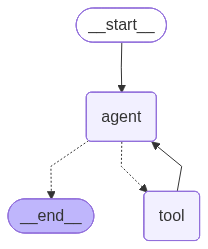

In [9]:
workflow = StateGraph(MessagesState)
tool_node = ToolNode(tools=tools)

workflow.add_node("agent", call_model)
workflow.add_node("tool", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tool", "agent")

graph = workflow.compile()
graph

In [10]:
from langchain_core.messages import HumanMessage

In [11]:
messages1 = [HumanMessage(content="Hello, how are you?")]
messages2 = [HumanMessage(content="How is the weather in munich?")]

In [12]:
graph.invoke({"messages": messages1})

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='f6f3ffca-694b-43f8-96b6-a0b6f9a4efa9'),
  AIMessage(content="Hello! I'm doing well, thank you. How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cc1d1-684f-7f61-b855-70468bfe28c0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 18, 'total_tokens': 64, 'input_token_details': {'cache_read': 0}})]}

In [13]:
graph.invoke({"messages": messages2})

{'messages': [HumanMessage(content='How is the weather in munich?', additional_kwargs={}, response_metadata={}, id='7f20e344-a7dc-4ccc-9e5b-ad9b46d16e5f'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "munich"}'}, '__gemini_function_call_thought_signatures__': {'7d133176-e01f-4ae4-bc00-1953de8cc43b': 'CukBAb4+9vtj7sQL5d/CNNLH4AT2Qv6hif+j001sP1W+TF/AhQYoJK5C/cW4k/3XBgKq6br+2r+AN6niIqAOrOanv5BliX1XW2QWcXZo+97adon6Crqy4sCeG7ARXCWshMnEC2rQtO5AzUju/cgHIx0PorNSaiU64A+7SyRjFqdKDuFBvTjD3qwnBrRBhRArQRSUdpdFnhwKHOu+X6F1mL+809QYf2yO/w8rdzknwZfS+mYJqoQbpDsJFJfiobAOBW52UOaDKQhC4cLBD1NGACzMJM2fkoDJoZVVSICWy4NlRxstsI8QQnXIIlM='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cc1d1-6b36-7da1-9e65-2ab9f8767a5d-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'munich'}, 'id': '7d133176-e01f-4ae4-bc00-1953de8cc43b', 'type': 

In [14]:
graph.invoke(
    {
        "messages": [
            HumanMessage(content="What would you recommend to do in that city than?")
        ]
    }
)

{'messages': [HumanMessage(content='What would you recommend to do in that city than?', additional_kwargs={}, response_metadata={}, id='232a902d-b82e-412a-80f9-4e45f7668289'),
  AIMessage(content=[{'type': 'text', 'text': 'I need to know which city you are referring to. Can you please tell me the city?', 'extras': {'signature': 'Cq4HAb4+9vsB4rIMlcw3BF4c7KlC2+sgwg/oKZqVQ6QXRFq0i89ZqEwWyxF+3EypSRxYn8+ul12OGvcTGCdYPXal9D4HmbIntHIx/egCpCY4yT1Q0CDq/TrKMVTMpsWDlWZxrThUSccotUoDc4bFWGqHvTm9Cr3cXuuyuvyciNASEBW/7DlhKETGXBLukaw92+AflIg+ku76m65nVbm/IWWR3YvGIpLv859Qd/nAB9E8ZiBHZsT7GppTKOdW8B8RpkZ26G3Vzwjw8nAdcWrAENoZskyw3Qwg3KKO79TpDskCDjv+ldVIzOiOj0A1vMwlNP3HA1x347WT1lpGiOtNAyonMmpUpJj2VPCHitVhUeToZkPOeuPGcpaCSfbhCjg528uV6/E66r6+zMwMeQzzDomuHYcw+SqT0Gog5mo104No+RiulqShcpJecGcwgLzt6Qg6k+0AK1W4N8LFxvi2xTY3/ngJeHt9q2oY5prL0B7y5M+jh+8wL1VHBJMgE+fN5XvlAHJC7nLw1oIM2Jc9VkT5X32+aGxo59UiiwkdlkpzfDJWPzzfb0NY2nMZmAJ1vfOd0mAPo5rm+vhB6MXhN1BGXhseanmUg/eL4dQnIscLnZYnZScL92eMUdasag7l0kX/FO4rsEvJGcBQD9wGmCHFQnZlR

##### Add Memory to chatbot


In [15]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

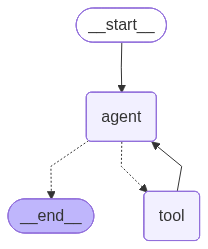

In [16]:
workflow = StateGraph(MessagesState)
tool_node = ToolNode(tools=tools)

workflow.add_node("agent", call_model)
workflow.add_node("tool", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tool", "agent")

graph = workflow.compile(checkpointer=checkpointer)
graph

In [17]:
graph.invoke(
    {
        "messages": [
            HumanMessage(content="How is the weather in munich?")
        ]
    },
    config={
        "configurable": {
            "thread_id": 1
        }
    }
)

{'messages': [HumanMessage(content='How is the weather in munich?', additional_kwargs={}, response_metadata={}, id='5020ab4d-949b-4385-8b7c-c2601afbf03b'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "munich"}'}, '__gemini_function_call_thought_signatures__': {'79ae80f6-0e85-4137-890f-3a5c77f70f55': 'CukBAb4+9vtF8lCBuxnVtGJqcOD/+LSF3QInY1+mXSIhBzwv/Cmqmiz1ujEotSogmcePjpoOArhj9GuwEDg0HZtGGRsY3QzIJOHIe/H2LpNsiyM+8TJQZrDB+0ZFk4AlrzINcH1JCyqRmqeCKajLrDL4ET6B38Zc1yV0B/jc9zFX6dmLHeHQbkpuzA/N3aTry1W4676PqkbQ7TJpit27htvpKGl19jKGz6/z4blAybveQc5FSlhxl/s7zVlToGeHkfsnBlIe1+FInAQP3BoXaLUQHgVxmICIFmeNiJ1zureLX0/VSu97G4OIVL8='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cc1d1-7e44-7ba2-af3f-450311924c45-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'munich'}, 'id': '79ae80f6-0e85-4137-890f-3a5c77f70f55', 'type': 

In [18]:
graph.invoke(
    {
        "messages": [
            HumanMessage(content="What would you recommend to do in that city than?")
        ]
    },
    config={"configurable": {"thread_id": 1}},
)

{'messages': [HumanMessage(content='How is the weather in munich?', additional_kwargs={}, response_metadata={}, id='5020ab4d-949b-4385-8b7c-c2601afbf03b'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "munich"}'}, '__gemini_function_call_thought_signatures__': {'79ae80f6-0e85-4137-890f-3a5c77f70f55': 'CukBAb4+9vtF8lCBuxnVtGJqcOD/+LSF3QInY1+mXSIhBzwv/Cmqmiz1ujEotSogmcePjpoOArhj9GuwEDg0HZtGGRsY3QzIJOHIe/H2LpNsiyM+8TJQZrDB+0ZFk4AlrzINcH1JCyqRmqeCKajLrDL4ET6B38Zc1yV0B/jc9zFX6dmLHeHQbkpuzA/N3aTry1W4676PqkbQ7TJpit27htvpKGl19jKGz6/z4blAybveQc5FSlhxl/s7zVlToGeHkfsnBlIe1+FInAQP3BoXaLUQHgVxmICIFmeNiJ1zureLX0/VSu97G4OIVL8='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cc1d1-7e44-7ba2-af3f-450311924c45-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'munich'}, 'id': '79ae80f6-0e85-4137-890f-3a5c77f70f55', 'type': 